In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

In [ ]:
(0.2870 + 0.3240 + 0.2758) / 3

In [ ]:
import torch

torch.tensor([0.2870, 0.3240, 0.2758]).std()

In [ ]:
data = [
    # Classification
    {"experiment": "Classification", "task": "FACED", "model": "Baseline", "value": 0.111, "error": 0.00},
    {"experiment": "Classification", "task": "FACED", "model": "CBraMod-Probe", "value": 0.104, "error": 0.011},
    {"experiment": "Classification", "task": "FACED", "model": "CBraMod-Finetune", "value": 0.41, "error": 0.02},
    {"experiment": "Classification", "task": "FACED", "model": "EEGAVI-Probe", "value": 0.104, "error": 0.008},
    {"experiment": "Classification", "task": "FACED", "model": "EEGAVI-Finetune", "value": 0.2956, "error": 0.0252},

    {"experiment": "Classification", "task": "EAV", "model": "Baseline", "value": 0.20, "error": 0.00},
    {"experiment": "Classification", "task": "EAV", "model": "CBraMod-Probe", "value": 0.218, "error": 0.002},
    {"experiment": "Classification", "task": "EAV", "model": "CBraMod-Finetune", "value": 0.41, "error": 0.02},
    {"experiment": "Classification", "task": "EAV", "model": "EEGAVI-Probe", "value": 0.413, "error": 0.002},
    {"experiment": "Classification", "task": "EAV", "model": "EEGAVI-Finetune", "value": 0.41, "error": 0.02},

    {"experiment": "Classification", "task": "CLARE", "model": "Baseline", "value": 0.718, "error": 0.00},
    {"experiment": "Classification", "task": "CLARE", "model": "CBraMod-Probe", "value": 0.718, "error": 0.01},
    {"experiment": "Classification", "task": "CLARE", "model": "CBraMod-Finetune", "value": 0.0, "error": 0.0},
    {"experiment": "Classification", "task": "CLARE", "model": "EEGAVI-Probe", "value": 0.703, "error": 0.009},
    {"experiment": "Classification", "task": "CLARE", "model": "EEGAVI-Finetune", "value": 0, "error": 0},

    # Regression
    {"experiment": "Regression", "task": "DEAP mixed", "model": "Baseline", "value": 0.261, "error": 0.000},
    {"experiment": "Regression", "task": "DEAP mixed", "model": "CBraMod", "value": 0.235, "error": 0.005},
    {"experiment": "Regression", "task": "DEAP mixed", "model": "EEGAVI", "value": 0.291, "error": 0.008},

    {"experiment": "Regression", "task": "DEAP cross", "model": "Baseline", "value": 0.261, "error": 0.000},
    {"experiment": "Regression", "task": "DEAP cross", "model": "CBraMod", "value": 0.240, "error": 0.006},
    {"experiment": "Regression", "task": "DEAP cross", "model": "EEGAVI", "value": 0.504, "error": 0.010},
]

In [ ]:
df = pd.DataFrame(data)

In [ ]:
def plot_grouped_by_experiment(
        df: pd.DataFrame,
        title: str = "Downstream performance",
        y_title: str = "Metric",
        output_html: str | None = None,
):
    required = {"experiment", "task", "model", "value"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    experiments = df["experiment"].drop_duplicates().tolist()
    models = df["model"].drop_duplicates().tolist()

    a = make_subplots(
        rows=1,
        cols=len(experiments),
        subplot_titles=experiments,
        shared_yaxes=False,
    )

    for col_idx, experiment in enumerate(experiments, start=1):
        dfe = df[df["experiment"] == experiment]
        tasks = dfe["task"].drop_duplicates().tolist()

        for model in models:
            dfm = dfe[dfe["model"] == model]

            # Keep task order stable
            x = tasks
            y = []
            err = []

            for task in tasks:
                row = dfm[dfm["task"] == task]
                if row.empty:
                    y.append(None)
                    err.append(None)
                else:
                    y.append(row["value"].iloc[0])
                    err.append(row["error"].iloc[0] if "error" in row.columns else None)

            a.add_trace(
                go.Bar(
                    name=model,
                    x=x,
                    y=y,
                    error_y=dict(type="data", array=err, visible="error" in df.columns),
                    legendgroup=model,
                    showlegend=(col_idx == 1),
                ),
                row=1,
                col=col_idx,
            )

    a.update_layout(
        title=title,
        barmode="group",
        template="plotly_white",
        height=500,
        width=max(900, 450 * len(experiments)),
        legend_title_text="Model",
    )

    for i in range(1, len(experiments) + 1):
        a.update_xaxes(title_text="Task", row=1, col=i)

    a.update_yaxes(title_text=y_title, row=1, col=1)

    if output_html:
        a.write_html(output_html)

    a.show()
    return a


r = plot_grouped_by_experiment(
    df,
    title="Downstream results grouped by experiment",
    y_title="Accuracy",
    output_html="downstream_grouped_by_experiment.html",
)

In [ ]:
data = [
    # Classification
    {"experiment": "Classification", "task": "FACED", "model": "Baseline", "value": 0.111, "error": 0.00},
    {"experiment": "Classification", "task": "FACED", "model": "CBraMod-Probe", "value": 0.104, "error": 0.011},
    {"experiment": "Classification", "task": "FACED", "model": "CBraMod-Finetune", "value": 0.41, "error": 0.02},
    {"experiment": "Classification", "task": "FACED", "model": "EEGAVI-Probe", "value": 0.104, "error": 0.008},
    {"experiment": "Classification", "task": "FACED", "model": "EEGAVI-Finetune", "value": 0.2956, "error": 0.0252},

    {"experiment": "Classification", "task": "EAV", "model": "Baseline", "value": 0.20, "error": 0.00},
    {"experiment": "Classification", "task": "EAV", "model": "CBraMod-Probe", "value": 0.218, "error": 0.002},
    {"experiment": "Classification", "task": "EAV", "model": "CBraMod-Finetune", "value": 0, "error": 0.02},
    {"experiment": "Classification", "task": "EAV", "model": "EEGAVI-Probe", "value": 0.413, "error": 0.002},
    {"experiment": "Classification", "task": "EAV", "model": "EEGAVI-Finetune", "value": 0.6, "error": 0.02},

    {"experiment": "Classification", "task": "CLARE", "model": "Baseline", "value": 0.718, "error": 0.00},
    {"experiment": "Classification", "task": "CLARE", "model": "CBraMod-Probe", "value": 0.718, "error": 0.01},
    {"experiment": "Classification", "task": "CLARE", "model": "CBraMod-Finetune", "value": 0.0, "error": 0.0},
    {"experiment": "Classification", "task": "CLARE", "model": "EEGAVI-Probe", "value": 0.703, "error": 0.009},
    {"experiment": "Classification", "task": "CLARE", "model": "EEGAVI-Finetune", "value": 0, "error": 0},
    # Regression
    #{"experiment": "Regression", "task": "DEAP mixed", "model": "Baseline", "value": 0.261, "error": 0.000},
    #{"experiment": "Regression", "task": "DEAP mixed", "model": "CBraMod", "value": 0.235, "error": 0.005},
    #{"experiment": "Regression", "task": "DEAP mixed", "model": "EEGAVI", "value": 0.291, "error": 0.008},

    #{"experiment": "Regression", "task": "DEAP cross", "model": "Baseline", "value": 0.261, "error": 0.000},
    #{"experiment": "Regression", "task": "DEAP cross", "model": "CBraMod", "value": 0.240, "error": 0.006},
    #{"experiment": "Regression", "task": "DEAP cross", "model": "EEGAVI", "value": 0.504, "error": 0.010},
]

In [ ]:
df = pd.DataFrame(data)

In [ ]:
r = plot_grouped_by_experiment(
    df,
    title="Downstream results grouped by experiment",
    y_title="Loss",
    output_html="downstream_grouped_by_experiment.html",
)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd


def plot_by_model_with_family_order(
        df: pd.DataFrame,
        title: str = "Downstream performance",
        y_title: str = "Metric",
        output_html: str | None = None,
):
    required = {"experiment", "model", "value"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    experiments = df["experiment"].drop_duplicates().tolist()
    model_order = [
        "Baseline",
        "CBraMod Probe",
        "CBraMod Fine-tune",
        "EEGAVI Probe",
        "EEGAVI Fine-tune",
    ]

    colors = {
        "Baseline": "#7f7f7f",
        "CBraMod Probe": "#1f77b4",
        "CBraMod Fine-tune": "#6baed6",
        "EEGAVI Probe": "#d62728",
        "EEGAVI Fine-tune": "#ff9896",
    }

    a = make_subplots(
        rows=1,
        cols=len(experiments),
        subplot_titles=experiments,
        shared_yaxes=False,
    )

    for col_idx, experiment in enumerate(experiments, start=1):
        dfe = df[df["experiment"] == experiment]

        for model in model_order:
            row = dfe[dfe["model"] == model]
            y = [row["value"].iloc[0]] if not row.empty else [None]
            err = [row["error"].iloc[0]] if ("error" in df.columns and not row.empty) else [None]

            a.add_trace(
                go.Bar(
                    x=[model],
                    y=y,
                    name=model,
                    marker_color=colors.get(model),
                    error_y=dict(type="data", array=err, visible="error" in df.columns),
                    legendgroup=model,
                    showlegend=(col_idx == 1),
                ),
                row=1,
                col=col_idx,
            )

    a.update_layout(
        title=title,
        template="plotly_white",
        barmode="group",
        height=500,
        width=max(900, 450 * len(experiments)),
        legend_title_text="Model",
    )

    for i in range(1, len(experiments) + 1):
        a.update_xaxes(title_text="Model", row=1, col=i)
    a.update_yaxes(title_text=y_title, row=1, col=1)

    if output_html:
        a.write_html(output_html)

    a.show()
    return a

In [ ]:
plot_by_model_with_family_order(df)

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _model_color(model: str) -> str:
    """
    Assign similar colors to the same model family.
    - Baseline: gray
    - CBraMod*: blues
    - EEGAVI*: reds
    """
    m = model.lower()

    if m == "baseline":
        return "#7f7f7f"

    if m.startswith("cbramod"):
        if "probe" in m:
            return "#4C78A8"   # darker blue
        if "finetune" in m:
            return "#9ECAE9"   # lighter blue
        return "#6BAED6"       # generic CBraMod blue

    if m.startswith("eegavi"):
        if "probe" in m:
            return "#E45756"   # darker red
        if "finetune" in m:
            return "#F4A6A6"   # lighter red
        return "#F28E8E"       # generic EEGAVI red

    return "#999999"


def plot_grouped_by_experiment(
        df: pd.DataFrame,
        title: str = "Downstream performance",
        y_title: str = "Metric",
        output_html: str | None = None,
):
    required = {"experiment", "task", "model", "value"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    experiments = df["experiment"].drop_duplicates().tolist()

    # Fixed model order so families stay visually grouped
    preferred_order = [
        "Baseline",
        "CBraMod-Probe",
        "CBraMod-Finetune",
        "EEGAVI-Probe",
        "EEGAVI-Finetune",
        "CBraMod",
        "EEGAVI",
    ]
    models_in_df = df["model"].drop_duplicates().tolist()
    models = [m for m in preferred_order if m in models_in_df] + [
        m for m in models_in_df if m not in preferred_order
    ]

    a = make_subplots(
        rows=1,
        cols=len(experiments),
        subplot_titles=experiments,
        shared_yaxes=False,
    )

    has_error = "error" in df.columns

    for col_idx, experiment in enumerate(experiments, start=1):
        dfe = df[df["experiment"] == experiment]
        tasks = dfe["task"].drop_duplicates().tolist()

        for model in models:
            dfm = dfe[dfe["model"] == model]

            x = tasks
            y = []
            err = []

            for task in tasks:
                row = dfm[dfm["task"] == task]
                if row.empty:
                    y.append(None)
                    err.append(None)
                else:
                    y.append(row["value"].iloc[0])
                    err.append(row["error"].iloc[0] if has_error else None)

            a.add_trace(
                go.Bar(
                    name=model,
                    x=x,
                    y=y,
                    marker_color=_model_color(model),
                    error_y=dict(type="data", array=err, visible=has_error),
                    legendgroup=model,
                    showlegend=(col_idx == 1),
                ),
                row=1,
                col=col_idx,
            )

    a.update_layout(
        title=title,
        barmode="group",
        template="plotly_white",
        height=500,
        width=max(950, 500 * len(experiments)),
        legend_title_text="Model",
    )

    for i in range(1, len(experiments) + 1):
        a.update_xaxes(title_text="Task", row=1, col=i)

    a.update_yaxes(title_text=y_title, row=1, col=1)

    if output_html:
        a.write_html(output_html)

    a.show()
    return a


r = plot_grouped_by_experiment(
    df,
    title="Downstream results grouped by experiment",
    y_title="Balanced-Accuracy",
    output_html="downstream_grouped_by_experiment.html",
)

In [9]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


data = [
    # modality, metric, setting, value, error
    ("Audio", "MRR", "Fused", 0.959, 0.003),
    ("Audio", "MRR", "EEG-only", 0.1127, 0.030),
    ("Audio", "MRR", "Pre-fusion EEG", 0.001, 5.06e-5),

    ("Audio", "Margin", "Fused", 0.311, 0.001),
    ("Audio", "Margin", "EEG-only", 0.1203, 0.009),
    ("Audio", "Margin", "Pre-fusion EEG", 0.0035, 0.0006),

    ("Audio", "Recall@1", "Fused", 0.935, 0.004),
    ("Audio", "Recall@1", "EEG-only", 0.055, 0.021),
    ("Audio", "Recall@1", "Pre-fusion EEG", 2.23e-4, 1.12e-4),

    ("Audio", "Recall@10", "Fused", 0.995, 0.001),
    ("Audio", "Recall@10", "EEG-only", 0.224, 0.048),
    ("Audio", "Recall@10", "Pre-fusion EEG", 0.001, 6.45e-5),

    ("ECG", "MRR", "Fused", 0.812, 0.014),
    ("ECG", "MRR", "EEG-only", 0.0307, 0.005),
    ("ECG", "MRR", "Pre-fusion EEG", 0.002, 3.44e-4),

    ("ECG", "Margin", "Fused", 0.434, 0.004),
    ("ECG", "Margin", "EEG-only", 0.1588, 0.008),
    ("ECG", "Margin", "Pre-fusion EEG", 0.003, 3.73e-4),

    ("ECG", "Recall@1", "Fused", 0.725, 0.019),
    ("ECG", "Recall@1", "EEG-only", 0.013, 9.11e-4),
    ("ECG", "Recall@1", "Pre-fusion EEG", 3.65e-4, 2.53e-4),

    ("ECG", "Recall@10", "Fused", 0.963, 0.005),
    ("ECG", "Recall@10", "EEG-only", 0.058, 0.014),
    ("ECG", "Recall@10", "Pre-fusion EEG", 0.003, 4.55e-4),

    ("EEG", "MRR", "Fused", 0.9513, 0.0038),
    ("EEG", "MRR", "EEG-only", 0.9645, 0.004),
    ("EEG", "MRR", "Pre-fusion EEG", None, None),

    ("EEG", "Margin", "Fused", 0.299, 0.002),
    ("EEG", "Margin", "EEG-only", 0.3517, 0.006),
    ("EEG", "Margin", "Pre-fusion EEG", None, None),

    ("EEG", "Recall@1", "Fused", 0.934, 0.005),
    ("EEG", "Recall@1", "EEG-only", 0.952, 0.006),
    ("EEG", "Recall@1", "Pre-fusion EEG", None, None),

    ("EEG", "Recall@10", "Fused", 0.981, 0.002),
    ("EEG", "Recall@10", "EEG-only", 0.986, 0.001),
    ("EEG", "Recall@10", "Pre-fusion EEG", None, None),

    ("Video", "MRR", "Fused", 0.712, 0.004),
    ("Video", "MRR", "EEG-only", 0.0493, 0.003),
    ("Video", "MRR", "Pre-fusion EEG", 5.63e-4, 7.79e-5),

    ("Video", "Margin", "Fused", 0.411, 0.013),
    ("Video", "Margin", "EEG-only", 0.0043, 0.003),
    ("Video", "Margin", "Pre-fusion EEG", 5.57e-4, 2.32e-4),

    ("Video", "Recall@1", "Fused", 0.584, 0.005),
    ("Video", "Recall@1", "EEG-only", 0.009, 5.06e-4),
    ("Video", "Recall@1", "Pre-fusion EEG", 1.88e-5, 3.26e-5),

    ("Video", "Recall@10", "Fused", 0.938, 0.004),
    ("Video", "Recall@10", "EEG-only", 0.142, 0.008),
    ("Video", "Recall@10", "Pre-fusion EEG", 5.08e-4, 2.46e-4),

    ("Mean", "MRR", "Fused", 0.859, 0.003),
    ("Mean", "MRR", "EEG-only", 0.2893, 0.0083),
    ("Mean", "MRR", "Pre-fusion EEG", 0.001, 1.46e-4),

    ("Mean", "Margin", "Fused", 0.463, 0.002),
    ("Mean", "Margin", "EEG-only", 0.1521, 0.0017),
    ("Mean", "Margin", "Pre-fusion EEG", 0.002, 2.0e-4),

    ("Mean", "Recall@1", "Fused", 0.794, 0.004),
    ("Mean", "Recall@1", "EEG-only", 0.257, 0.006),
    ("Mean", "Recall@1", "Pre-fusion EEG", 2.02e-4, 1.29e-4),

    ("Mean", "Recall@10", "Fused", 0.969, 6.64e-4),
    ("Mean", "Recall@10", "EEG-only", 0.353, 0.012),
    ("Mean", "Recall@10", "Pre-fusion EEG", 0.002, 2.20e-4),
]

df = pd.DataFrame(data, columns=["modality", "metric", "setting", "value", "error"])


def plot_retrieval_results(df: pd.DataFrame, output_html: str | None = None):
    metric_order = ["MRR", "Margin", "Recall@1", "Recall@10"]
    modality_order = ["Audio", "ECG", "EEG", "Video", "Mean"]
    setting_order = ["Fused", "EEG-only", "Pre-fusion EEG"]

    colors = {
        "Fused": "#4C78A8",
        "EEG-only": "#F58518",
        "Pre-fusion EEG": "#E45756",
    }

    a = make_subplots(
        rows=2,
        cols=2,
        subplot_titles=metric_order,
        shared_yaxes=False,
    )

    positions = {
        "MRR": (1, 1),
        "Margin": (1, 2),
        "Recall@1": (2, 1),
        "Recall@10": (2, 2),
    }

    for metric in metric_order:
        row, col = positions[metric]
        df_metric = df[df["metric"] == metric]

        for setting in setting_order:
            df_setting = df_metric[df_metric["setting"] == setting]

            y = []
            err = []

            for modality in modality_order:
                row_df = df_setting[df_setting["modality"] == modality]
                if row_df.empty:
                    y.append(None)
                    err.append(None)
                else:
                    y.append(row_df["value"].iloc[0])
                    err.append(row_df["error"].iloc[0])

            a.add_trace(
                go.Bar(
                    name=setting,
                    x=modality_order,
                    y=y,
                    marker_color=colors[setting],
                    error_y=dict(type="data", array=err, visible=True),
                    legendgroup=setting,
                    showlegend=(metric == "MRR"),
                ),
                row=row,
                col=col,
            )

    a.update_layout(
        title="",
        template="plotly_white",
        barmode="group",
        height=800,
        width=1100,
        legend_title_text="Setting",
    )

    for r in [1, 2]:
        for c in [1, 2]:
            a.update_xaxes(title_text="Modality", row=r, col=c)

    if output_html:
        a.write_html(output_html)

    a.show()
    return a


a = plot_retrieval_results(df, output_html="retrieval_results_grouped.html")

In [11]:
a.write_image("retrieval_results.svg")

In [8]:
a.write_image("plot.png", width=2400, height=1600, scale=2)

In [7]:
a.update_layout(
    font=dict(size=18),
    title_font=dict(size=24),
    legend_title_font=dict(size=18),
    legend_font=dict(size=16),
)
a.update_xaxes(tickfont=dict(size=16), title_font=dict(size=18))
a.update_yaxes(tickfont=dict(size=16), title_font=dict(size=18))

In [12]:
a.update_layout(
    height=650,                  # smaller overall figure
    width=900,                   # narrower
    margin=dict(l=40, r=20, t=60, b=40),
    bargap=0.12,                 # less gap between category groups
    bargroupgap=0.03,            # less gap inside grouped bars
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
    ),
)

In [13]:
a.write_image("retrieval_results.svg")

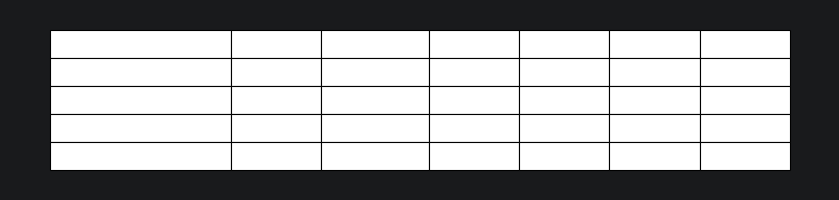

In [17]:
import matplotlib.pyplot as plt

data = [
    ["AMIGOS", "40", "16+4", "✓", "✓", "✓", "✓"],
    ["EAV", "42", "200", "✓", "✓", "✓", "✗"],
    ["DEAP", "32", "40", "✓", "✓", "✗", "✗"],
    ["MAHNOB", "29", "20 (1*)", "✓", "✓", "✗", "✓"],
]

columns = ["Dataset", "Subj.", "Exp.", "EEG", "Vid.", "Aud.", "ECG"]

fig, ax = plt.subplots(figsize=(8.5, 2.1))
ax.axis("off")

tbl = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.20, 0.10, 0.12, 0.10, 0.10, 0.10, 0.10],
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.1, 1.5)

for (r, c), cell in tbl.get_celld().items():
    cell.set_linewidth(0.8)
    if r == 0:
        cell.set_text_props(weight="bold")
    elif c >= 3:
        txt = cell.get_text().get_text()
        if txt == "Yes":
            cell.get_text().set_color("green")
            cell.get_text().set_weight("bold")
        elif txt == "No":
            cell.get_text().set_color("red")
            cell.get_text().set_weight("bold")

plt.tight_layout()
plt.savefig("datasets_table.png", dpi=300, bbox_inches="tight")
plt.show()